In [1]:
import numpy as np
import opt_einsum as oe
import matplotlib.pyplot as plt
import scipy as sp

from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal import integration_scheme

from quant_rotor.Hamiltonian_models.Dense.heisenberg_operators import heisenberg_operators
from quant_rotor.Hamiltonian_models.Dense.hamiltonian import hamiltonian_dense as ham
from quant_rotor.Hamiltonian_models.Dense.rotor_operators import rotor_operators
from quant_rotor.Hamiltonian_models.Dense.NO_transfrorm import NO_transform

from quant_rotor.Hamiltonian_models.Dense.combine_hamiltonian import combine_hamiltonian as ham_comb

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_periodic import t_periodic

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_guess import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state, amplitute_energy, intermediate_normalisation

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_sub_class import (
    QuantumSimulation,
    SimulationParams,
    TensorData,
)

from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import U as U_stat

In [2]:
np.set_printoptions(precision=8)
np.set_printoptions(suppress=True)
np.set_printoptions(linewidth=np.inf)
np.set_printoptions(threshold=np.inf)

# CCC interative

In [3]:
n_comb_sites = 4
site_comb = 2
site = n_comb_sites * site_comb

state = 2
state_comb = state**n_comb_sites

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.7

periodic = False

In [11]:
K, V = heisenberg_operators(J_x, J_y, J_z, h_x, h_y, h_z, g)
H = ham(site, K, V, V, periodic)

eig_val, eig_vec = np.linalg.eigh(H)

In [12]:
H_comb, K_comb, V_comb_xy, V_comb_yx = ham_comb(site, site_comb, K, V, periodic)

eig_val_comb, eig_vec_comb = np.linalg.eigh(H_comb)

In [15]:
K_NO, V_NO_xy, basis = NO_transform(state_comb, state_comb, H_comb, K_comb, V_comb_xy)
# V_NO = V_NO*0

matrix_p_to_NO_V = np.kron(basis, basis)

V_NO_yx = matrix_p_to_NO_V.conj().T @ V_comb_yx @ matrix_p_to_NO_V

H_NO = ham(site_comb, K_NO, V_NO_xy, V_NO_yx, periodic)

eig_val_NO, eig_vec_NO = np.linalg.eigh(H_NO)

[-0.         -0.         -0.         -0.         -0.          0.          0.          0.          0.          0.          0.          0.          0.00475509  0.0642021   0.0642021   0.8668407 ]
[[ 0.        +0.j  0.        +0.j  0.        +0.j -0.        -0.j  0.        +0.j -0.        -0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j -0.        -0.j -0.        -0.j  1.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.07435935+0.j  0.06450752+0.j -0.02890307+0.j -0.        +0.j  0.        +0.j  0.        +0.j -0.        +0.j -0.        +0.j  0.0388135 +0.j -0.0375946 +0.j -0.02747392+0.j  0.33158883+0.j  0.81593666+0.j  0.        +0.j -0.        +0.j  0.4583619 +0.j]
 [ 0.24076386+0.j  0.25245819+0.j -0.11002397+0.j -0.        +0.j  0.        +0.j  0.        +0.j -0.        +0.j -0.        +0.j  0.14753847+0.j -0.15434391+0.j -0.11746388+0.j  0.66991302+0.j  0.        +0.j  0.        +0.j -0.        +0.j -0.59834897+0.j]
 [-0.61992726+0.j  0.22366125

In [18]:
t_1_exact = t_1_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_NO, eig_val_NO)
t_2_exact = t_2_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_NO, eig_val_NO)

In [17]:
time, energy, one_max, two_max = integration_scheme(site_comb, state_comb, K_NO, V_NO_xy.reshape(state_comb, state_comb, state_comb, state_comb), V_NO_yx.reshape(state_comb, state_comb, state_comb, state_comb), t_init=0,t_final=10,nof_points=10000, periodic=periodic, import_guess=True, t_1_import=t_1_exact, t_2_import=t_2_exact)

KeyboardInterrupt: 

In [ ]:
# plt.plot(time, ED_U_val, label=f"Exact U g = {g}")
plt.plot(time, energy, label=f"Imag Time g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy[-1])
print("Exact: ", eig_val_NO[0])

NameError: name 'time' is not defined

In [7]:
energy[0] - eig_val_NO[0]

NameError: name 'energy' is not defined

In [8]:
plt.plot(time, one_max, label=f"Imag Time g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

NameError: name 'time' is not defined

In [9]:
plt.plot(time, two_max, label=f"Imag Time g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

NameError: name 'time' is not defined

Define Data Classes.

In [19]:
p = state_comb
i = 1
a = p - i

epsilon = np.diag(K_NO)

In [20]:
params = SimulationParams(
    a=a,
    i=i,
    p=p,  # These can be the same as `a + i` or chosen independently
    site=site_comb,
    state=state_comb,
    i_method=3,
    gap=False,
    gap_site=3,
    epsilon=epsilon,
    periodic=periodic,
)

tensors = TensorData(
    t_a_i_tensor=t_1_exact,
    t_ab_ij_tensor=t_2_exact,
    h_full=K_NO,
    v_full_xy=V_NO_xy.reshape(state_comb, state_comb, state_comb, state_comb),
    v_full_yx=V_NO_yx.reshape(state_comb, state_comb, state_comb, state_comb),
)

qs = QuantumSimulation(params, tensors)

In [21]:
energy_1 = 0
energy_2 = 0

if periodic:
    # energy calculations
    for site_x in range(site_comb):
        energy_1 += np.einsum("ip, pi->", qs.h_term(i, p), qs.B_term(i, site_x))

        for site_y in range(site_x + 1, site_x + site_comb):
            if abs(site_x - site_y) == 1 or abs(site_x - site_y) == (site - 1):
                # noinspection SpellCheckingInspection
                energy_2 += (
                    np.einsum(
                        "ijab, abij->",
                        qs.v_term(i, i, a, a, site_x, site_y % site),
                        qs.t_term(site_x, site_y % site),
                    )
                    * 0.5
                )
                # noinspection SpellCheckingInspection
                energy_2 += (
                    np.einsum(
                        "ijpq, pi, qj->",
                        qs.v_term(i, i, p, p, site_x, site_y % site),
                        qs.B_term(i, site_x),
                        qs.B_term(i, site_y % site),
                    )
                    * 0.5
                )
else:
    # energy calculations
    for site_x in range(site_comb):
        energy_1 += np.einsum("ip, pi->", qs.h_term(i, p), qs.B_term(i, site_x))

        for site_y in range(site_comb):
            if site_x < site_y:
                # noinspection SpellCheckingInspection
                energy_2 += np.einsum(
                    "ijab, abij->",
                    qs.v_term(i, i, a, a, site_x, site_y % site),
                    qs.t_term(site_x, site_y % site),
                )
                # noinspection SpellCheckingInspection
                energy_2 += np.einsum(
                    "ijpq, pi, qj->",
                    qs.v_term(i, i, p, p, site_x, site_y % site),
                    qs.B_term(i, site_x),
                    qs.B_term(i, site_y % site),
                )

In [22]:
energy_1 + energy_2 - eig_val[0]

np.complex128(0j)

In [23]:
np.max(t_1_exact)

np.complex128(0.06537395605233269-0j)

In [24]:
C_1 = np.einsum(
    "pi, qj->pqij",
    qs.B_term(i, 0),
    qs.B_term(i, 1))

In [25]:
C_1[1:, 1:] += t_2_exact[0, 1]

In [26]:
L_h = np.einsum(
    "pP, Pqij->pqij",
    qs.h_term(p, p),
    C_1)

L_h += np.einsum(
    "pQij, qQ->pqij",
    C_1,
    qs.h_term(p, p))

L_h -= energy_1 * C_1

In [27]:
L_V = np.einsum("pqPQ, PQij -> pqij", qs.v_term(p, p, p, p, 0, 1), C_1) - energy_2 * C_1

In [28]:
single = np.zeros((site_comb, a, i), dtype=complex)
double = np.zeros((site_comb, site_comb, a, a, i, i), dtype=complex)

for x_site in range(site_comb):
    single[x_site] = qs.residual_single(x_site)
    for y_site in range(site_comb):
        if x_site < y_site:
            double[x_site, y_site] = qs.residual_double_total(x_site, y_site)

In [ ]:
T_1, T_2, R_h_1_1 = t_periodic(site_comb, state_comb, K_NO, V_comb_xy.reshape(state_comb, state_comb, state_comb, state_comb), V_comb_yx.reshape(state_comb, state_comb, state_comb, state_comb), "original", Import_t=True, t_1_import=t_1_exact, t_2_import=t_2_exact, periodic=periodic)

original


ValueError: Diverges.

In [ ]:
R_0_1 = R_h_0_1 + R_V_0_1
R_1_0 = R_h_1_0 + R_V_1_0
R_1_1 = R_h_1_1 + R_V_1_1

In [ ]:
R_h_0_1

In [ ]:
R_0_1

In [ ]:
R_1_0

In [ ]:
R_1_1

In [ ]:
L_h[1:, 0, 0, 0] - R_h_1_0.T

In [ ]:
L_h[0, 1:, 0, 0] - R_h_0_1.T

In [ ]:
L_h[1:, 1:,] - R_h_1_1 - np.einsum("ai, bj->abij", R_h_1_0, t_1_exact[1]) - np.einsum("ai, bj->abij", t_1_exact[0], R_h_0_1)

In [ ]:
L_V[1:, 1:,] - R_V_1_1 - np.einsum("ai, bj->abij", R_V_1_0, t_1_exact[1]) - np.einsum("ai, bj->abij", t_1_exact[0], R_V_0_1)

In [ ]:
L_V[1:, 0, 0, 0] - R_V_1_0.T

In [ ]:
L_V[0, 1:, 0, 0] - R_V_0_1.T

# Rotor Check

In [13]:
site = 2
state = 11

g = 0.1

periodic = False

In [14]:
K, V = rotor_operators(state, g)
H = ham(site, K, V, periodic)

eig_val, eig_vec = np.linalg.eigh(H)

In [15]:
t_1_exact = t_1_amplitude_guess_ground_state(state, site, eig_vec, eig_val)
t_2_exact = t_2_amplitude_guess_ground_state(state, site, eig_vec, eig_val)

In [16]:
t_1_exact_save = t_1_amplitude_guess_ground_state(state, site, eig_vec, eig_val)
t_2_exact_save = t_2_amplitude_guess_ground_state(state, site, eig_vec, eig_val)

In [17]:
E, E_0, E_1 = amplitute_energy(site, state, periodic, K, V.reshape(state, state, state, state), t_1_exact, t_2_exact)

In [18]:
eig_val[0]

np.float64(-0.006236057649215084)

In [19]:
E

np.complex128(-0.006236057649215084+0j)

In [20]:
# R_1, R_2, T_1, T_2 = t_periodic(site, state, K, V.reshape(state, state, state, state), V.reshape(state, state, state, state), Import_t=True, t_1_import=t_1_exact, t_2_import=t_2_exact, periodic=periodic, one_cicle=True)

In [21]:
# np.max(R_1)

In [22]:
# np.max(R_2)

In [23]:
a = state - 1
i = 1

In [24]:
t_2_exact_save[0,1].reshape(a, a)

array([[ 0.03740819-0.j,  0.01249658-0.j, -0.        -0.j,  0.        -0.j,  0.00000438-0.j,  0.00000146-0.j, -0.        -0.j,  0.        -0.j,  0.        -0.j,  0.        -0.j],
       [ 0.01249658-0.j,  0.03740819-0.j, -0.        -0.j,  0.        -0.j,  0.00000146-0.j,  0.00000438-0.j, -0.        -0.j,  0.        -0.j,  0.        -0.j,  0.        -0.j],
       [-0.        -0.j, -0.        +0.j,  0.00035025+0.j,  0.00003883+0.j, -0.        -0.j,  0.        +0.j,  0.00000002+0.j,  0.        +0.j, -0.        +0.j,  0.        +0.j],
       [-0.        -0.j, -0.        +0.j,  0.00003883+0.j,  0.00035025+0.j, -0.        -0.j,  0.        +0.j,  0.        +0.j,  0.00000002+0.j, -0.        +0.j,  0.        +0.j],
       [ 0.00000438-0.j,  0.00000146-0.j, -0.        -0.j, -0.        -0.j,  0.00000146-0.j,  0.00000005-0.j, -0.        -0.j,  0.        -0.j,  0.        -0.j,  0.        -0.j],
       [ 0.00000146-0.j,  0.00000438-0.j, -0.        -0.j, -0.        -0.j,  0.00000005-0.j,  0.00000146-

In [25]:
np.max(t_2_exact_save[0,1]  - (t_2_exact_save[0, 1].reshape(a, a).T).reshape(a, a, i, i))

np.complex128(6.074480198902638e-20+0j)

In [26]:
# _, _, e, R_1, R_2, T_1, T_2 = t_periodic(site, state, K, V.reshape(state, state, state, state), V.reshape(state, state, state, state), Import_t=True, t_1_import=t_1_exact, t_2_import=t_2_exact, periodic=periodic)

In [27]:
time, energy, one_max, two_max = integration_scheme(site, state, K, V.reshape(state, state, state, state), V.reshape(state, state, state, state), t_init=0,t_final=10,nof_points=10000, periodic=periodic, import_guess=True, t_1_import=t_1_exact, t_2_import=t_2_exact)

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


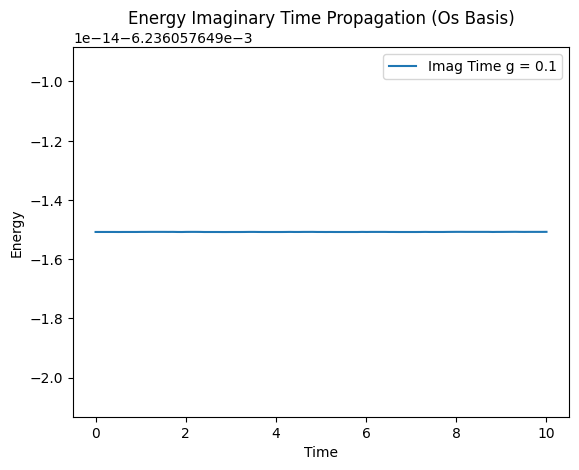

TF (-0.00623605764921508+0j)
Exact:  -0.006016055578001839


In [29]:
# plt.plot(time, ED_U_val, label=f"Exact U g = {g}")
plt.plot(time, energy, label=f"Imag Time g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy[-1])
print("Exact: ", ED_U_val[-1])

In [30]:
energy[-1] - eig_val[0]

np.complex128(4.336808689942018e-18+0j)

# Magnetic

In [3]:
n_comb_sites = 4
site_comb = 2
site = n_comb_sites * site_comb

state = 2
state_comb = state**n_comb_sites

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.7

periodic = False

In [4]:
K, V = heisenberg_operators(J_x, J_y, J_z, h_x, h_y, h_z, g)
H = ham(site, K, V, periodic)

eig_val, eig_vec = np.linalg.eigh(H)

In [5]:
H_comb, K_comb, V_comb_xy, V_comb_yx = ham_comb(site, site_comb, K, V, periodic)

eig_val_comb, eig_vec_comb = np.linalg.eigh(H_comb)

In [6]:
K_NO, V_NO_xy, basis = NO_transform(state_comb, state_comb, H_comb, K_comb, V_comb_xy)
# V_NO = V_NO*0
H_NO = ham(site_comb, K_NO, V_NO_xy, periodic)


matrix_p_to_NO_V = np.kron(basis, basis)

V_NO_yx = matrix_p_to_NO_V.conj().T @ V_comb_yx @ matrix_p_to_NO_V

eig_val_NO, eig_vec_NO = np.linalg.eigh(H_NO)

[-0.         -0.         -0.         -0.         -0.          0.          0.          0.          0.          0.          0.          0.          0.00475509  0.0642021   0.0642021   0.8668407 ]
[[ 0.        +0.j  0.        +0.j  0.        +0.j -0.        -0.j  0.        +0.j -0.        -0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j -0.        -0.j -0.        -0.j  1.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.07435935+0.j  0.06450752+0.j -0.02890307+0.j -0.        +0.j  0.        +0.j  0.        +0.j -0.        +0.j -0.        +0.j  0.0388135 +0.j -0.0375946 +0.j -0.02747392+0.j  0.33158883+0.j  0.81593666+0.j  0.        +0.j -0.        +0.j  0.4583619 +0.j]
 [ 0.24076386+0.j  0.25245819+0.j -0.11002397+0.j -0.        +0.j  0.        +0.j  0.        +0.j -0.        +0.j -0.        +0.j  0.14753847+0.j -0.15434391+0.j -0.11746388+0.j  0.66991302+0.j  0.        +0.j  0.        +0.j -0.        +0.j -0.59834897+0.j]
 [-0.61992726+0.j  0.22366125

In [7]:
t_1_exact = t_1_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_NO, eig_val_NO)
t_2_exact = t_2_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_NO, eig_val_NO)

In [8]:
time, energy, one_max, two_max = integration_scheme(site_comb, state_comb, K_NO, V_NO_xy.reshape(state_comb, state_comb, state_comb, state_comb), V_NO_yx.reshape(state_comb, state_comb, state_comb, state_comb), t_init=0,t_final=10,nof_points=10000, periodic=periodic, import_guess=True, t_1_import=t_1_exact, t_2_import=t_2_exact)

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


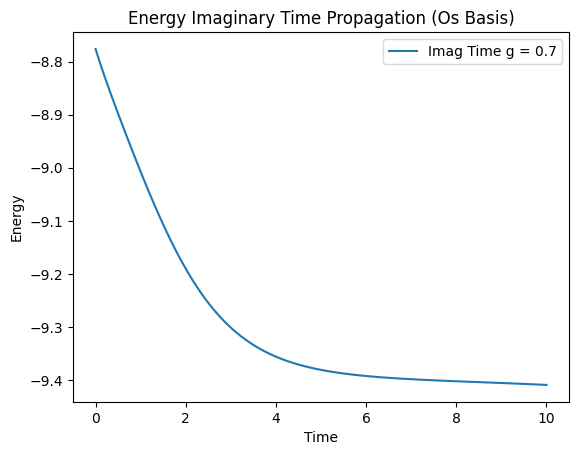

TF (-9.409325157686183+0j)
Exact:  -8.776063778933688


In [9]:
# plt.plot(time, ED_U_val, label=f"Exact U g = {g}")
plt.plot(time, energy, label=f"Imag Time g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy[-1])
print("Exact: ", eig_val_NO[0])

In [28]:
eig_val_K, eig_vec_K = np.linalg.eigh(K_comb)

K_K = eig_vec_K.T.conj() @ K_comb @ eig_vec_K
V_K_xy = np.kron(eig_vec_K, eig_vec_K).T.conj() @ V_comb_xy @ np.kron(eig_vec_K, eig_vec_K)
V_K_yx = np.kron(eig_vec_K, eig_vec_K).T.conj() @ V_comb_yx @ np.kron(eig_vec_K, eig_vec_K)


In [30]:
E_0 = K_K[0, 0]*2

In [32]:
V_K_yx.reshape(state_comb, state_comb, state_comb, state_comb)[0, 0, 0, 0]

np.complex128(0j)

In [13]:

K_K = K_K - np.eye(state_comb) * K_K[0, 0]
V_K_xy = V_K_xy - np.eye(state_comb**2) * V_K_xy.reshape(state_comb, state_comb, state_comb, state_comb)[0, 0, 0, 0]
V_K_xy = V_K_xy - np.eye(state_comb**2) * V_K_xy.reshape(state_comb, state_comb, state_comb, state_comb)[0, 0, 0, 0]

H_K = ham(site_comb, K_K, V_K_xy, periodic)

eig_val_K_comb, eig_vec_K_comb = np.linalg.eigh(H_K)

t_1_exact_K = t_1_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_K_comb, eig_val_K_comb)
t_2_exact_K = t_2_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_K_comb, eig_val_K_comb)

In [43]:
R_1, R_2, T_1, T_2 = t_periodic(site_comb, state_comb, K_K, V_K_xy.reshape(state_comb, state_comb, state_comb, state_comb), V_K_yx.reshape(state_comb, state_comb, state_comb, state_comb), Import_t=True, t_1_import=t_1_exact_K, t_2_import=t_2_exact_K, periodic=periodic, one_cicle=True)

R_2: (0.7325397144146227+0j)
R_1: (3.129898532637757e-18+0j)


In [46]:
np.max(R_2)

np.complex128(0.3662698572073115+0j)

In [41]:
t_1_exact_K

array([[[ 0.        +0.j],
        [ 0.        +0.j],
        [ 0.09155907+0.j],
        [ 0.        +0.j],
        [-0.05232427+0.j],
        [ 0.        +0.j],
        [-0.        +0.j],
        [ 0.        +0.j],
        [-0.0237219 +0.j],
        [ 0.        +0.j],
        [ 0.        +0.j],
        [ 0.        +0.j],
        [-0.        +0.j],
        [ 0.        +0.j],
        [ 0.        +0.j]],

       [[ 0.        +0.j],
        [ 0.        +0.j],
        [-0.09155907+0.j],
        [ 0.        +0.j],
        [-0.05232427+0.j],
        [ 0.        +0.j],
        [-0.        +0.j],
        [ 0.        +0.j],
        [ 0.0237219 +0.j],
        [-0.        +0.j],
        [-0.        +0.j],
        [ 0.        +0.j],
        [ 0.        +0.j],
        [-0.        +0.j],
        [-0.        +0.j]]])

In [42]:
np.max(t_2_exact_K)

np.complex128(0.24369664342283598+0j)

In [14]:
K_K[0, 0]

np.complex128(0j)

In [15]:
eig_val

array([-8.77606378, -8.63113934, -8.17606378, -8.14492444, -8.03113934, -8.        , -7.54492444, -7.4       , -7.26227868, -7.11735424, -6.66227868, -6.63113934, -6.51735424, -6.4862149 , -6.28984888, -6.14492444, -6.03113934, -5.8862149 , -5.68984888, -5.65870954, -5.54492444, -5.5137851 , -5.37606378, -5.23113934, -5.05870954, -4.9137851 , -4.77606378, -4.77606378, -4.74492444, -4.63113934, -4.63113934, -4.63113934, -4.6       , -4.4862149 , -4.17606378, -4.14492444, -4.14492444, -4.14492444, -4.03113934, -4.03113934, -4.        , -4.        , -4.        , -4.        , -3.8862149 , -3.86227868, -3.85507556, -3.71735424, -3.54492444, -3.54492444, -3.5137851 , -3.4       , -3.4       , -3.4       , -3.36886066, -3.26227868, -3.25507556, -3.23113934, -3.11735424, -3.11735424, -3.0862149 , -2.97242979, -2.9137851 , -2.88984888, -2.76886066, -2.74492444, -2.63113934, -2.63113934, -2.51735424, -2.4862149 , -2.4862149 , -2.4862149 , -2.37242979, -2.34129046, -2.28984888, -2.25870954, -2.14

In [16]:
eig_val_K_comb

array([-0.24556861, -0.10064417,  0.35443139,  0.38557073,  0.49935583,  0.53049517,  0.98557073,  1.13049517,  1.26821649,  1.41314093,  1.86821649,  1.89935583,  2.01314093,  2.04428027,  2.24064629,  2.38557073,  2.49935583,  2.64428027,  2.84064629,  2.87178563,  2.98557073,  3.01671007,  3.15443139,  3.29935583,  3.47178563,  3.61671007,  3.75443139,  3.75443139,  3.78557073,  3.89935583,  3.89935583,  3.89935583,  3.93049517,  4.04428027,  4.35443139,  4.38557073,  4.38557073,  4.38557073,  4.49935583,  4.49935583,  4.53049517,  4.53049517,  4.53049517,  4.53049517,  4.64428027,  4.66821649,  4.67541961,  4.81314093,  4.98557073,  4.98557073,  5.01671007,  5.13049517,  5.13049517,  5.13049517,  5.16163451,  5.26821649,  5.27541961,  5.29935583,  5.41314093,  5.41314093,  5.44428027,  5.55806537,  5.61671007,  5.64064629,  5.76163451,  5.78557073,  5.89935583,  5.89935583,  6.01314093,  6.04428027,  6.04428027,  6.04428027,  6.15806537,  6.18920471,  6.24064629,  6.27178563,  6.38

In [33]:
E_0

np.complex128(-8.530495168499707+0j)

In [17]:
time_K, energy_K, one_max_K, two_max_K = integration_scheme(site_comb, state_comb, K_K, V_K_xy.reshape(state_comb, state_comb, state_comb, state_comb), V_K_yx.reshape(state_comb, state_comb, state_comb, state_comb), t_init=0,t_final=10,nof_points=10000, periodic=periodic, import_guess=True, t_1_import=t_1_exact_K, t_2_import=t_2_exact_K)

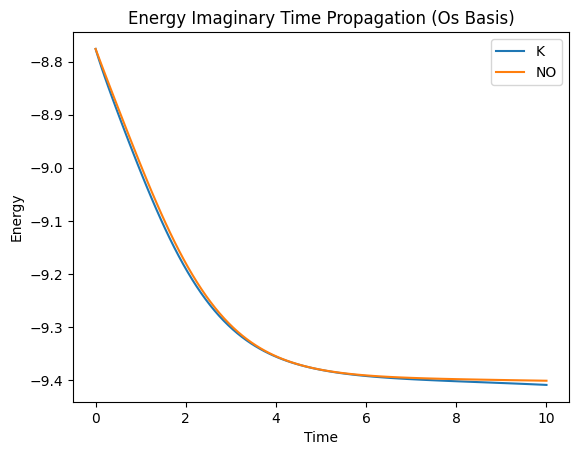

TF (-9.409325157686183+0j)
Exact:  -8.776063778933688


In [37]:
plt.plot(time, energy, label=f"K")
plt.plot(time_K, energy_K + E_0, label=f"NO")

plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy[-1])
print("Exact: ", eig_val_NO[0])

In [39]:
one_max_K[-1]

np.complex128(0.5484679909221225+0j)

In [40]:
two_max_K[-1]

np.complex128(-1.1255819993146856+0j)

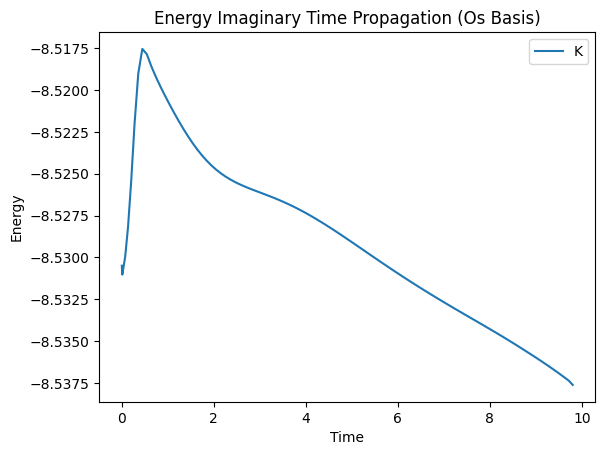

In [26]:
plt.plot(time[:104], energy[:104] - energy_K, label=f"K")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()
